# L02 - Matplotlib - Exercises Solution

In [1]:
# import pandas and matplotlib packages before trying out the exercises below
import pandas as pd
import matplotlib.pyplot as plt

## Exercise 1: Automating Annotations
Dataset: StockData/AAPL.csv (or any other ticker in StockData folder) 

Task:
1. Load the Apple stock data stored in AAPL.csv into a pandas data frame. Filter the data to just 2010-2019.
2. Plot the 'Adj Close' as a time series plot.
3. Label the title along with the X and Y axis.
4. Find the global minimum and maximum share prices. Store these values in variables so that you can annotate them on the graph.

Challenge: Find and annotate the min and max for each year. This can be done in a loop.

Learning goals: Practice plotting time series data, annotating and labeling graphs with matplotlib.

### Main Question

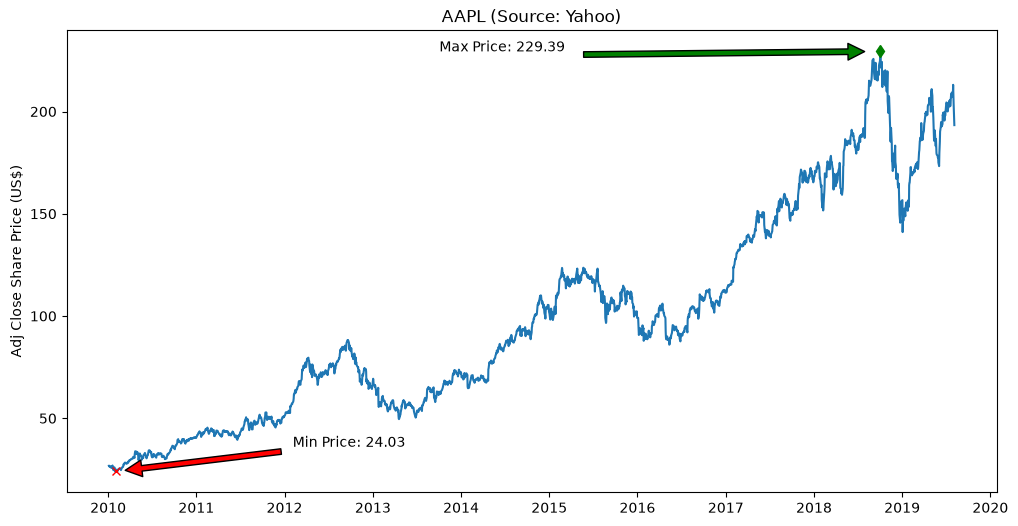

In [3]:
# Load data
aapl = pd.read_csv("Data/StockData/AAPL.csv", index_col=['Date'], parse_dates=['Date'])
aapl = aapl.loc['2010':'2019']

# Find the global min/max share prices
maxPrice = aapl['Adj Close'].max()
maxPriceDate = aapl['Adj Close'].idxmax()
minPrice = aapl['Adj Close'].min()
minPriceDate = aapl['Adj Close'].idxmin()

#2 Plot time series and annotations 
plt.figure(figsize=(12,6))
plt.plot(aapl.index, aapl['Adj Close'])
plt.plot(minPriceDate, minPrice, marker='x', color='red')
plt.plot(maxPriceDate, maxPrice, marker='d', color='green')
plt.title('AAPL (Source: Yahoo)')
plt.annotate(f'Max Price: {maxPrice:.2f}', xy=(maxPriceDate,maxPrice), 
                xytext=(maxPriceDate + pd.offsets.DateOffset(years=-5), maxPrice),
                arrowprops=dict(facecolor="green", shrink=0.05))
plt.annotate(f'Min Price: {minPrice:.2f}', xy=(minPriceDate,minPrice),
                xytext=(minPriceDate  + pd.offsets.DateOffset(years=2), minPrice*1.5), 
                arrowprops=dict(facecolor="red", shrink=0.05))
plt.ylabel("Adj Close Share Price (US$)") 
plt.show()

### Challenge Question

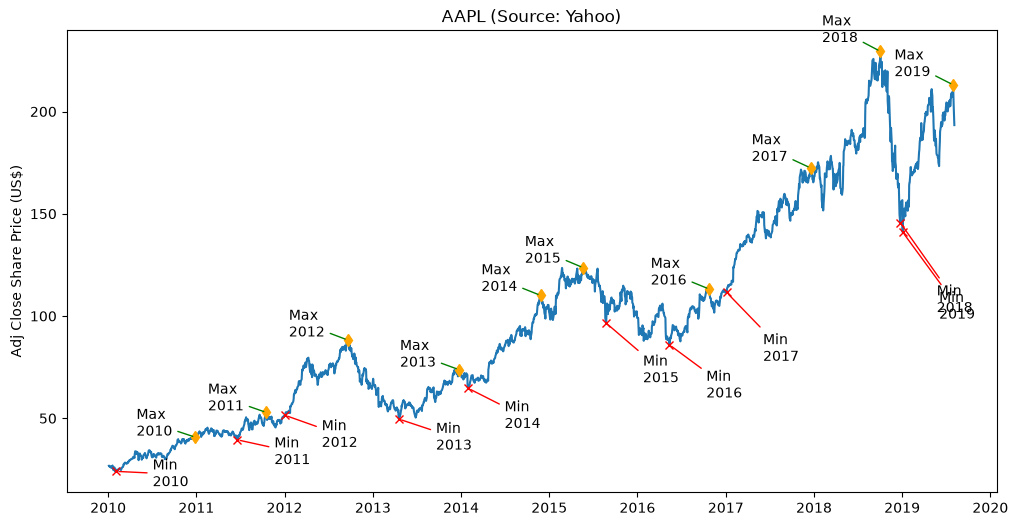

In [4]:
#challenge question - min/max price of each year
minyear = min(aapl.index.year)
maxyear = max(aapl.index.year)

plt.figure(figsize=(12,6))
plt.plot(aapl.index, aapl['Adj Close'])
plt.title('AAPL (Source: Yahoo)')
plt.ylabel("Adj Close Share Price (US$)") 

for year in range(minyear, maxyear + 1):
    maxPrice = aapl.loc[str(year)]['Adj Close'].max()
    maxPriceDate = aapl.loc[str(year)]['Adj Close'].idxmax()
    minPrice = aapl.loc[str(year)]['Adj Close'].min()
    minPriceDate = aapl.loc[str(year)]['Adj Close'].idxmin()

    plt.plot(minPriceDate, minPrice, marker='x', color='red')
    plt.plot(maxPriceDate, maxPrice, marker='d', color='orange')

    plt.annotate(f"Max\n{year}", xy=(maxPriceDate,maxPrice), 
                    xytext=(maxPriceDate + pd.offsets.DateOffset(months=-8), maxPrice*1.02),
                    arrowprops=dict(color="green", arrowstyle='-'))
    plt.annotate(f'Min\n{year}', xy=(minPriceDate,minPrice),
                    xytext=(minPriceDate  + pd.offsets.DateOffset(months=5), minPrice*0.70), 
                    arrowprops=dict(color="red", arrowstyle='-'))
plt.show()

## Exercise 2: Multiple Graphs with Subplots

Dataset: Multiple ticker files in StockData folder.

Task:
1. Load the stock data for the following tickers: AAPL, DIS, HD, INTC, NKE, MSFT.
2. Create a subplot with 3 rows and 2 columns.
3. Plot the 'Adj Close' for each ticker. Remember to set the title and label the y-axis of each graph.

Challenge: Use loops to automate the process to load the data, concatenate into a single data frame.

Learning goals: Practice loading data from multiple files and creating multiple plots using subplots.

### Main Question

In [6]:
aapl = pd.read_csv('Data/StockData/AAPL.csv', index_col=['Date'], parse_dates=['Date'])
dis = pd.read_csv('Data/StockData/DIS.csv', index_col=['Date'], parse_dates=['Date'])
hd = pd.read_csv('Data/StockData/HD.csv', index_col=['Date'], parse_dates=['Date'])
intc = pd.read_csv('Data/StockData/INTC.csv', index_col=['Date'], parse_dates=['Date'])
nke = pd.read_csv('Data/StockData/NKE.csv', index_col=['Date'], parse_dates=['Date'])
msft = pd.read_csv('Data/StockData/MSFT.csv', index_col=['Date'], parse_dates=['Date'])

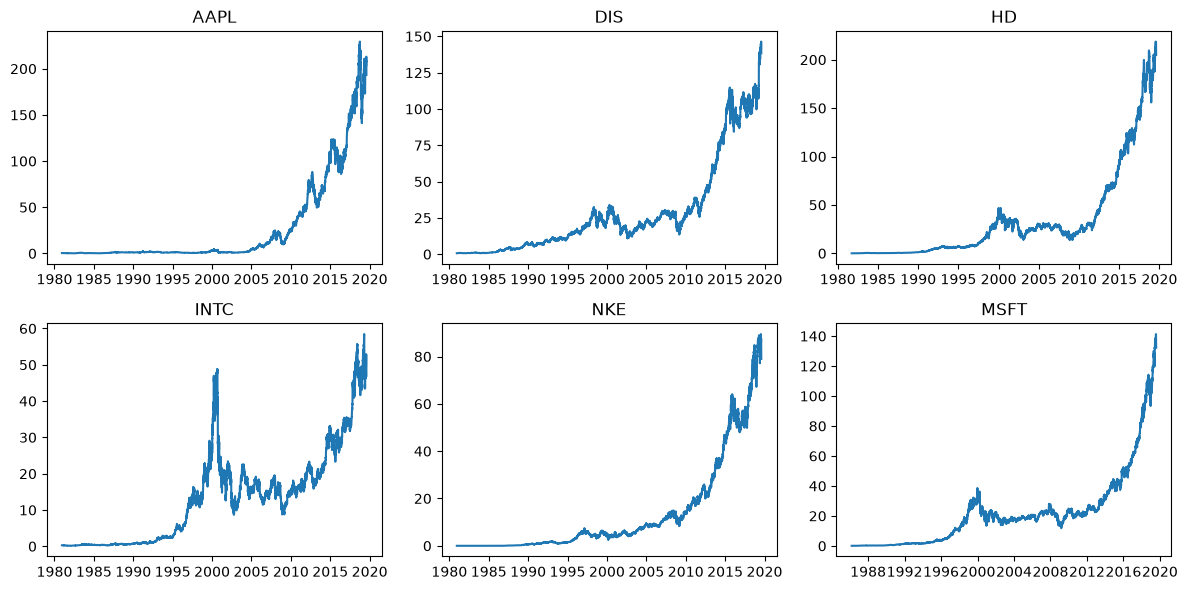

In [7]:
numRows = 2
numCols = 3

plt.figure(figsize=(12,6))

plt.subplot(numRows, numCols, 1)
plt.plot(aapl.index, aapl['Adj Close'])
plt.title("AAPL")

plt.subplot(numRows, numCols, 2)
plt.plot(dis.index, dis['Adj Close'])
plt.title("DIS")

plt.subplot(numRows, numCols, 3)
plt.plot(hd.index, hd['Adj Close'])
plt.title("HD")

plt.subplot(numRows, numCols, 4)
plt.plot(intc.index, intc['Adj Close'])
plt.title("INTC")

plt.subplot(numRows, numCols, 5)
plt.plot(nke.index, nke['Adj Close'])
plt.title("NKE")

plt.subplot(numRows, numCols, 6)
plt.plot(msft.index, msft['Adj Close'])
plt.title("MSFT")

plt.tight_layout()
plt.show()

### Challenge Question

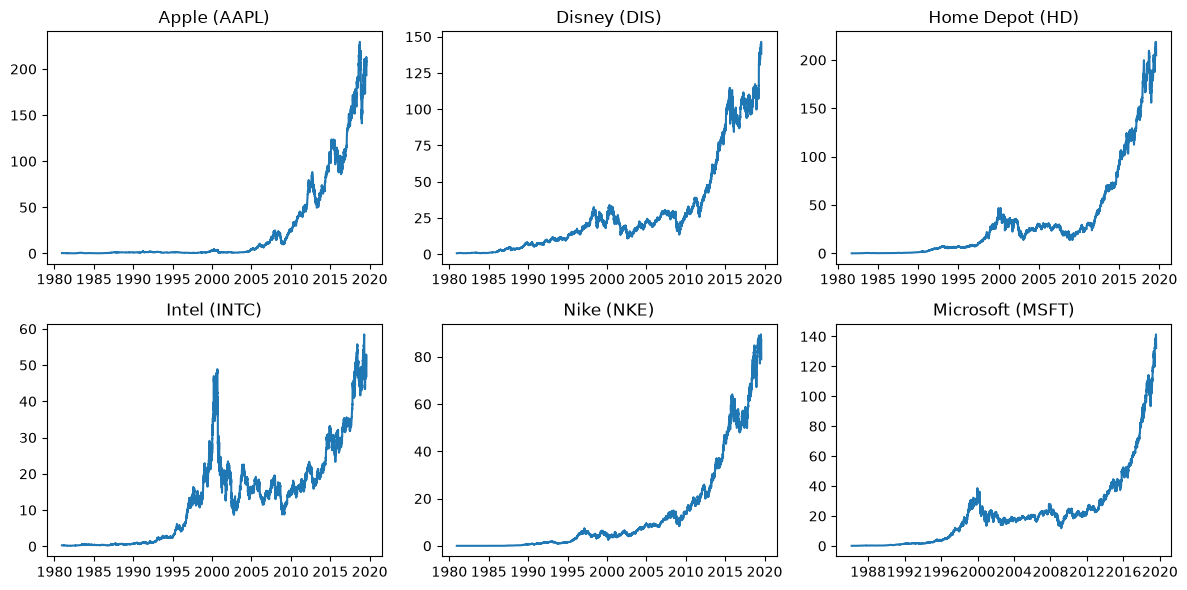

In [9]:
tickers = ['AAPL', 'DIS', 'HD', 'INTC', 'NKE', 'MSFT']
companies = ['Apple', 'Disney', 'Home Depot', 'Intel', 'Nike', 'Microsoft']

dfs = [] #list to store all tbles

#Load all data
for ticker in tickers:
    df = pd.read_csv('Data/StockData/'+ticker+'.csv', index_col=['Date'], parse_dates=['Date'])
    df['Ticker'] = ticker
    dfs.append(df)

#Plot the data
numRows = 2
numCols = 3
plt.figure(figsize=(12,6))
for idx, ticker in enumerate(tickers): #idx = index of each ticker in list, ticker = each ticker in list
    company = companies[idx]
    plt.subplot(numRows, numCols, idx+1)
    df = dfs[idx]
    plt.plot(df.index, df['Adj Close'])
    plt.title(f"{company} ({ticker})")
    
plt.tight_layout()

plt.show()